## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'

In [3]:
dataset_monthly = pd.read_csv(f"../data/{NUTS0}_WNV_Dataset_GRID_2009_2022.csv", encoding = enc)
dataset_monthly

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,5.03,15.31,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,3.61,18.39,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,3,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,3.61,19.09,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,4,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,4.573572,12.160266,19.701893,137.207154,1081.966519,137.207154,8.15,25.89,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0
4,

In [4]:
dataset_monthly.cases.sum()

1380

<Axes: >

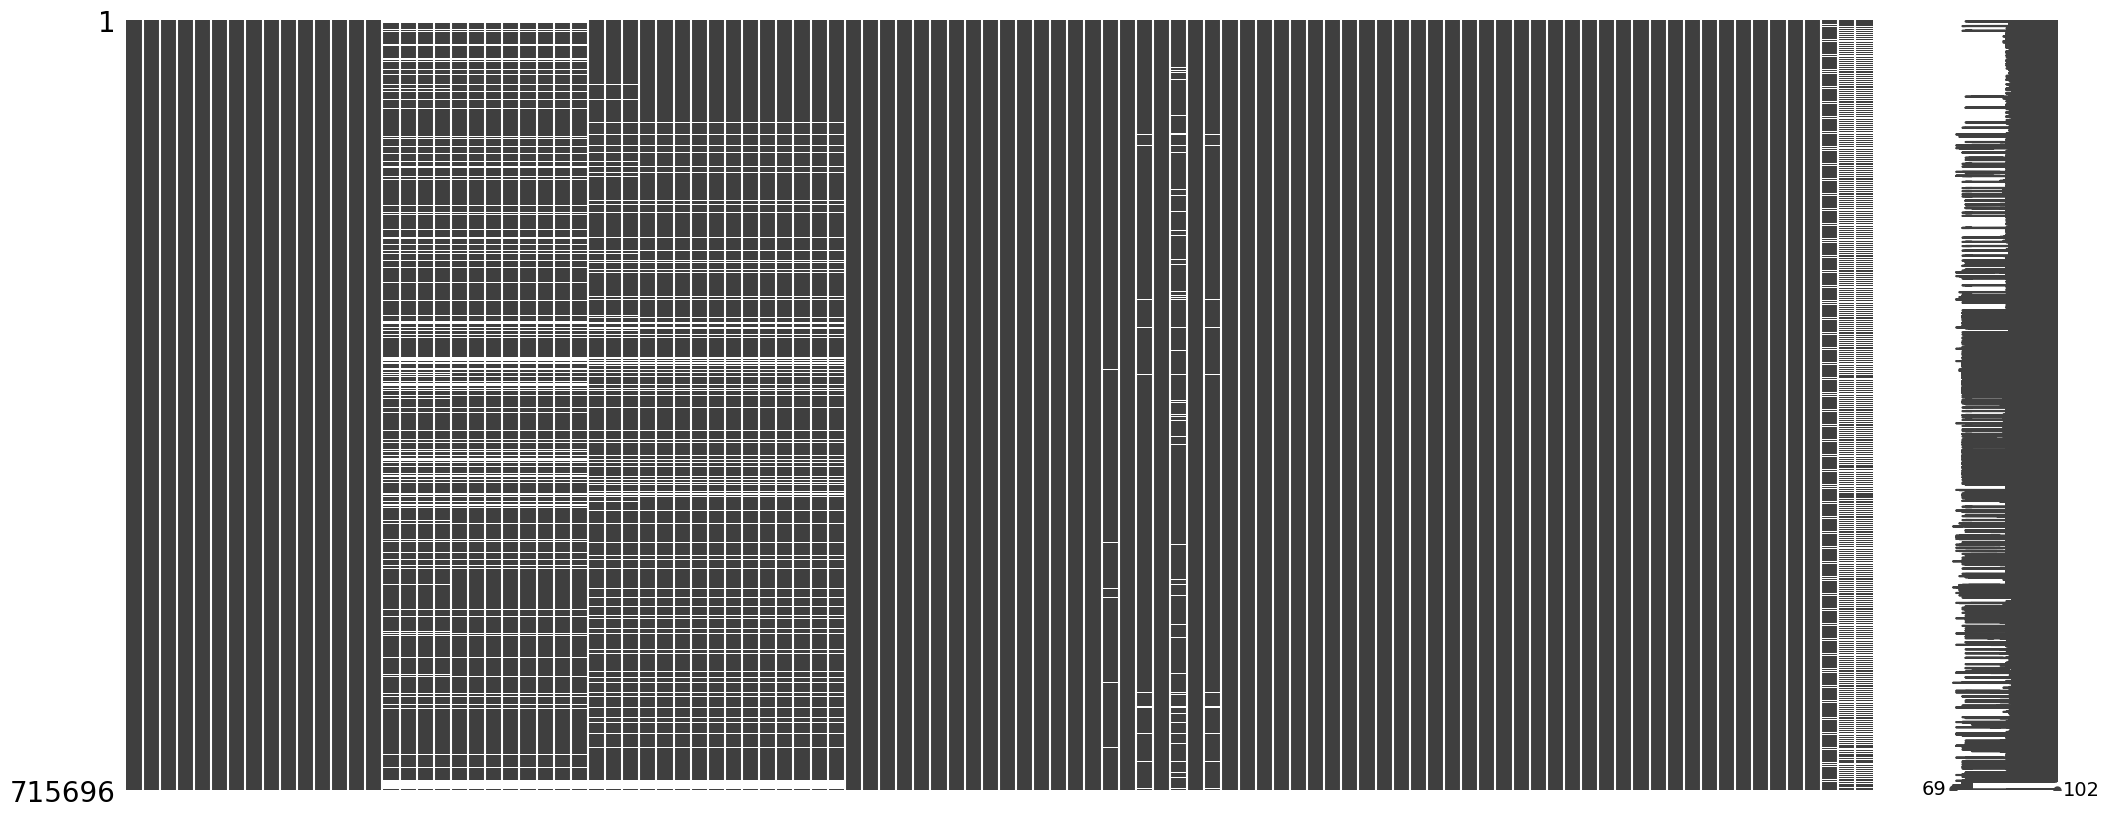

In [5]:
missingno.matrix(dataset_monthly)

In [6]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
15,ndvi,15.7218
16,ndmi,15.7218
17,ndwi,15.7218
18,ndbi,15.7218
19,ndvi_mean,15.0298
...,...,...
61,lc_prop2_assessment,7.3407
63,lc_prop3_assessment,1.4151
99,MIO_EUR,14.2855
100,L_TOTAL,48.7145


In [7]:
all_columns = dataset_monthly.columns.to_list()

In [8]:
len(dataset_monthly.columns)

102

In [9]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME', 'cell_code', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 'cases']

In [10]:
len(desired_order)

99

In [11]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [12]:
result

['rainfall_acc', 'NUTS1_NAME', 'NUTS1_ID']

In [13]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [14]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,cell_code,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,cases
0,2009-01,EL43,κρητη,EL434,αποκορωνου,AAE407,24.117404,35.410691,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,13.385833,11.985000,15.888065,21.939333,7.764194,7.764194,10.422857,7.003548,10.883333,10.811250,10.575013,11.203929,11.445806,16.411333,5.03,15.31,11.289533,89.988620,121.504665,347.327549,349.975530,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,2009-02,EL43,κρητη,EL434,αποκορωνου,AAE407,24.117404,35.410691,2,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,13.385833,11.985000,15.888065,21.939333,10.422857,7.764194,10.422857,7.003548,10.883333,11.203929,10.575013,11.203929,11.445806,16.411333,3.61,18.39,14.562216,133.844776,205.302734,422.839291,757.717577,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
2,2009-03,EL43,κρητη,EL434,αποκορωνου,AAE407,24.117404,35.410691,3,2009,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,13.385833,11.985000,15.888065,21.939333,7.003548,7.764194,10.422857,7.003548,10.883333,11.445806,10.575013,11.203929,11.445806,16.411333,3.61,19.09,6.033606,16.994903,36.774120,174.351656,944.759366,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,2009-04,EL43,κρητη,EL434,αποκορωνου,AAE407,24.117404,35.410691,4,2009,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,13.385833,11.985000,15.888065,21.939333,10.883333,7.764194,10.422857,7.003548,10.883333,16.411333,10.575013,11.203929,11.445806,16.411333,8.15,25.89,4.573572,12.160266,19.701893,137.207154,1081.966519,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.0,29.0,10.5,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,22,72.0,20,72.0,20,72.0,9,9,4,1,1,2,0,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,2009-05,EL43,κρητη,EL434,αποκορωνου,AAE407,24.117404,35.410691,5,2009,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.

In [15]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_code.unique()

In [16]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_code'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_code': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [17]:
dataset_monthly[(dataset_monthly['cell_code'] == 'AAE407') & (dataset_monthly['year'] == 2020)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,cell_code,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,cases
132,2020-01,AAE407,24.117404,35.410691,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.551290,9.55129,17.046552,18.777097,20.192,6.413226,6.413226,8.30931,8.897097,10.471333,7.982258,7.982258,12.677931,13.837097,15.331667,3.590,16.290,10.125120,54.763468,59.154121,302.675191,313.878730,19.291667,17.416667,45.833333,705.645524,41.0,3.0,38.0,16.5,28.0,28.0,10.5,1845.0,490.0,2.0,106.091634,1087.0,17.0,17.0,703.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,21,68.0,20,68.0,20,68.0,8,8,4,1,1,2,0,13043.0,51080.0,14614.0,78737.0,12690.0,51433.0,17033.0,81156.0,2026.39,4555.0,4575.0,2,2,1,0
133,2020-02,AAE407,24.117404,35.410691,2,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.046552,9.55129,17.046552,18.777097,20.192,8.309310,6.413226,8.30931,8.897097,10.471333,12.677931,7.982258,12.677931,13.837097,15.331667,4.710,19.670,5.745906,26.173332,53.211568,171.876524,480.510009,19.291667,17.416667,45.833333,705.645524,41.0,3.0,38.0,16.5,28.0,28.0,10.5,1845.0,490.0,2.0,106.091634,1087.0,17.0,17.0,703.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,21,68.0,20,68.0,20,68.0,8,8,4,1,1,2,0,13043.0,51080.0,14614.0,78737.0,12690.0,51433.0,17033.0,81156.0,2026.39,4555.0,4575.0,2,2,1,0
134,2020-03,AAE407,24.117404,35.410691,3,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.777097,9.55129,17.046552,18.777097,20.192,8.897097,6.413226,8.30931,8.897097,10.471333,13.837097,7.982258,12.677931,13.837097,15.331667,4.510,23.670,4.531782,54.344040,62.770643,140.485241,620.995250,19.291667,17.416667,45.833333,705.645524,41.0,3.0,38.0,16.5,28.0,28.0,10.5,1845.0,490.0,2.0,106.091634,1087.0,17.0,17.0,703.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,21,68.0,20,68.0,20,68.0,8,8,4,1,1,2,0,13043.0,51080.0,14614.0,78737.0,12690.0,51433.0,17033.0,81156.0,2026.39,4555.0,4575.0,2,2,1,0
135,2020-04,AAE407,24.117404,35.410691,4,2020,0.480085,0.137727,-0.394717,-0.137727,0.509577,0.155149,-0.429474,-0.155149,0.029867,0.038493,0.025134,0.038493,20.192000,9.55129,17.046552,18.777097,20.192,10.471333,6.413226,8.30931,8.897097,10.471333,15.331667,7.982258,12.677931,13.837097,15.331667,8.670,27.750,1.761306,9.985647,37.307037,52.839175,673.834425,19.291667,17.416667,45.833333,705.645524,41.0,3.0,38.0,16.5,28.0,28.0,10.5,1845.0,490.0,2.0,106.091634,1087.0,17.0,17.0,703.0,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,21,68.0,20,68.0,20,68.0,8,8,4,1,1,2,0,13043.0,51080.0,14614.0,78737.0,12690.0,51433.0,17033.0,81156.0,2026.39,4555.0,4575.0,2,2,1,0
136,2020-05,AAE407,24.117404,35.410691,5,2020,0.419074,0.071185,-0.382744,-0.071185,0.424416,0.093227,-0.386127,-0.093227,0.045977,0.040034,0.037319,0.040034,28.199677,9.55129,17.046552,18.777097,20.192,14.932581,6.413226,8.30931,8.897097,10.471333,21.566129,7.982258,12.677931,13.837097,15.331667,10.890,34.890,0.736854,9.189083,14.476207,22.842482,696.676907,19.291667,17.416667,45.833333,705.645524,41.0,3.0,38.0,16.5,28.0,28.0,10.5,1845.0,4

In [18]:
dataset_operational[(dataset_operational['cell_code'] == 'AAE407') & (dataset_operational['year'] == 2020)]

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
511200,AAE407,EL43,EL434,αποκορωνου,2020,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.110645,9.55129,17.046552,18.777097,20.192,10.364194,6.413226,8.30931,8.897097,10.471333,12.737419,7.982258,12.677931,13.837097,15.331667,6.590,19.410,9.963362,92.205887,123.311944,308.864233,313.878730,18.875,18.083333,44.105691,749.583218,39.0,-2.0,41.0,9.5,27.833333,27.833333,9.5,2134.0,624.0,1.0,112.82411,1388.0,58.0,58.0,1273.0,21,20,20,8,8,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,13037.0,51275.0,14356.0,78668.0,12677.0,51402.0,16829.0,80908.0,2384.69,5752.0,5433.0,2,2,1,0
515460,AAE407,EL43,EL434,αποκορωνου,2020,2,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.551290,9.55129,17.046552,18.777097,20.192,6.413226,6.413226,8.30931,8.897097,10.471333,7.982258,7.982258,12.677931,13.837097,15.331667,3.590,16.290,10.125120,54.763468,59.154121,302.675191,480.510009,18.875,18.083333,44.105691,749.583218,39.0,-2.0,41.0,9.5,27.833333,27.833333,9.5,2134.0,624.0,1.0,112.82411,1388.0,58.0,58.0,1273.0,21,20,20,8,8,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,13037.0,51275.0,14356.0,78668.0,12677.0,51402.0,16829.0,80908.0,2384.69,5752.0,5433.0,2,2,1,0
519720,AAE407,EL43,EL434,αποκορωνου,2020,3,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.046552,9.55129,17.046552,18.777097,20.192,8.309310,6.413226,8.30931,8.897097,10.471333,12.677931,7.982258,12.677931,13.837097,15.331667,4.710,19.670,5.745906,26.173332,53.211568,171.876524,620.995250,18.875,18.083333,44.105691,749.583218,39.0,-2.0,41.0,9.5,27.833333,27.833333,9.5,2134.0,624.0,1.0,112.82411,1388.0,58.0,58.0,1273.0,21,20,20,8,8,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,13037.0,51275.0,14356.0,78668.0,12677.0,51402.0,16829.0,80908.0,2384.69,5752.0,5433.0,2,2,1,0
523980,AAE407,EL43,EL434,αποκορωνου,2020,4,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.777097,9.55129,17.046552,18.777097,20.192,8.897097,6.413226,8.30931,8.897097,10.471333,13.837097,7.982258,12.677931,13.837097,15.331667,4.510,23.670,4.531782,54.344040,62.770643,140.485241,673.834425,18.875,18.083333,44.105691,749.583218,39.0,-2.0,41.0,9.5,27.833333,27.833333,9.5,2134.0,624.0,1.0,112.82411,1388.0,58.0,58.0,1273.0,21,20,20,8,8,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.0,52.950027,13037.0,51275.0,14356.0,78668.0,12677.0,51402.0,16829.0,80908.0,2384.69,5752.0,5433.0,2,2,1,0
528240,AAE407,EL43,EL434,αποκορωνου,2020,5,24.117404,35.410691,0.480085,0.137727,-0.394717,-0.137727,0.509577,0.155149,-0.429474,-0.155149,0.029867,0.038493,0.025134,0.038493,20.192000,9.55129,17.046552,18.777097,20.192,10.471333,6.413226,8.30931,8.897097,10.471333,15.331667,7.982258,12.677931,13.837097,15.331667,8.670,27.750,1.761306,9.985647,37.307037,52.839175,696.676907,18.875,18.083333,44.105691,749.583218,39.0,-2.0,41.0,9.5,27.833333,27.833333,9.5,2134.0,624.0,1.0,112.82411,1388.0,58.0,58

<Axes: >

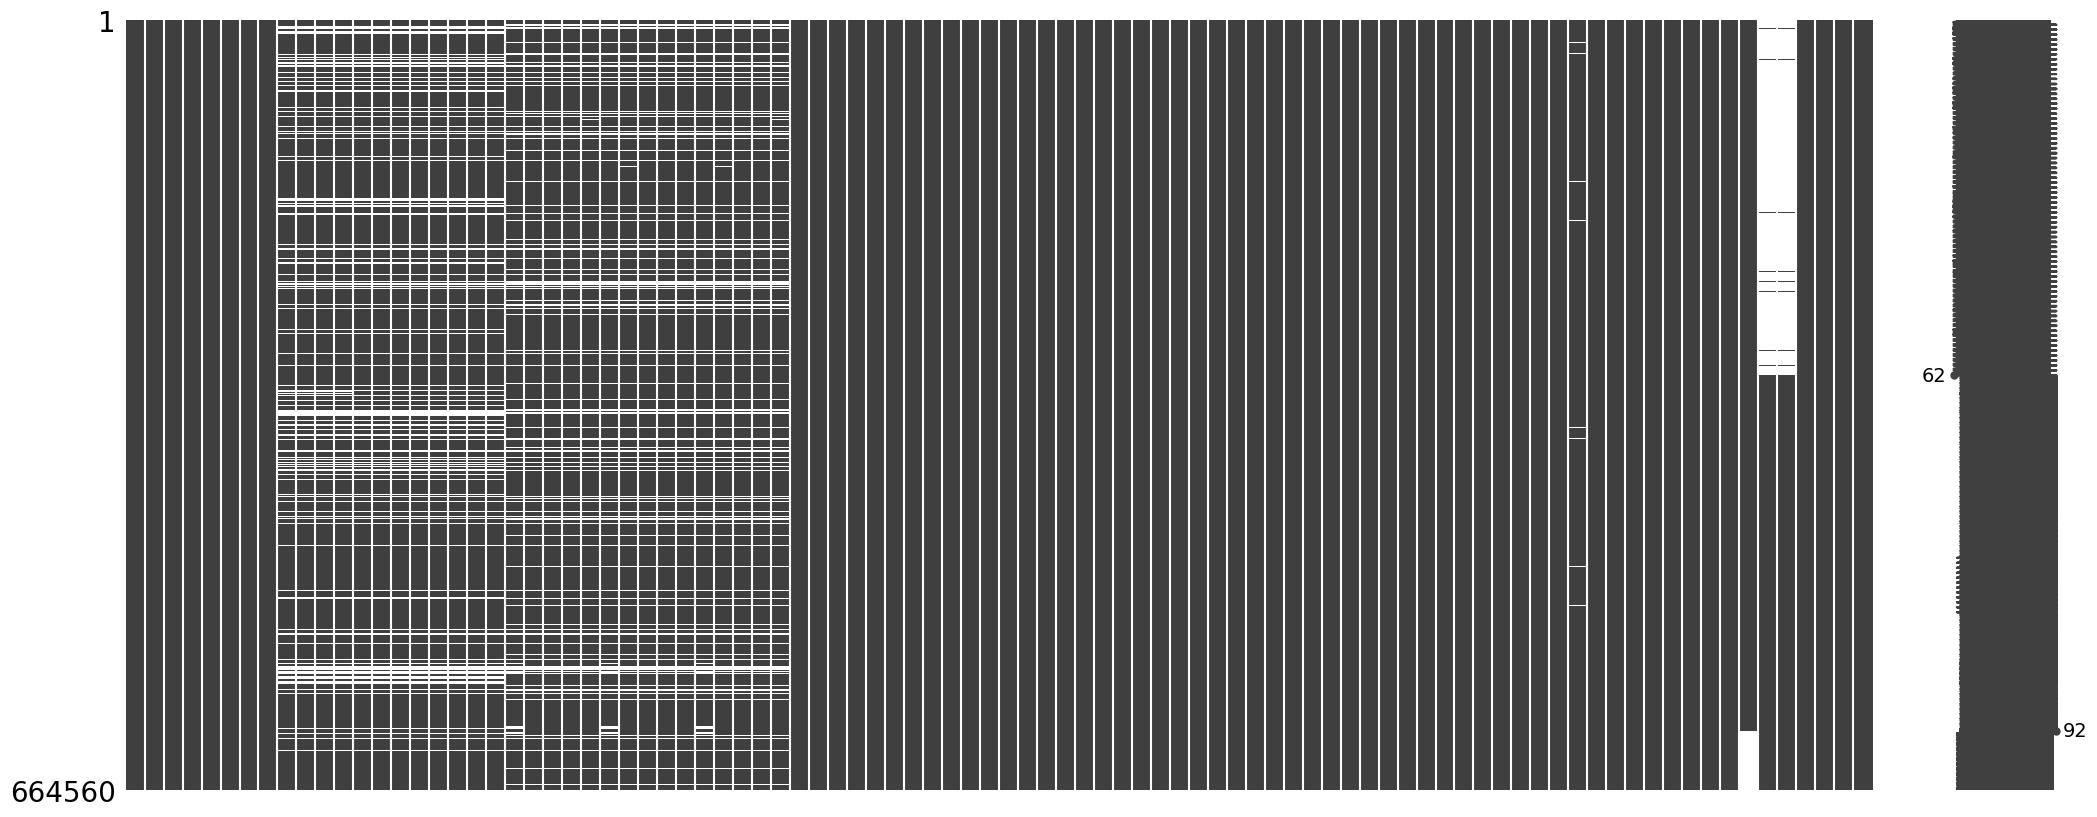

In [19]:
missingno.matrix(dataset_operational)

In [20]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,14.5940
9,ndmi,14.5940
10,ndwi,14.5940
11,ndbi,14.5940
12,ndvi_mean,13.9339
...,...,...
34,lst_apr_mean,10.7385
76,flow_accu_200m,0.7746
85,mio_eur,7.6923
86,l_total,44.7707


In [21]:
dataset_monthly.cases.sum()

1380

In [22]:
dataset_operational.cases.sum()

1364

In [23]:
dataset_operational.to_csv(f"../data/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv", encoding = enc, index = False)